<a href="https://colab.research.google.com/github/prasad2154/NewVision/blob/main/GenAI/RAG/8_rag_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RAG - Retrieval-Augmented Generation

LLMs are powerful, but they have a problem:

They don't know **your** data.

**RAG** solves this: retrieve relevant context first, then generate a response.

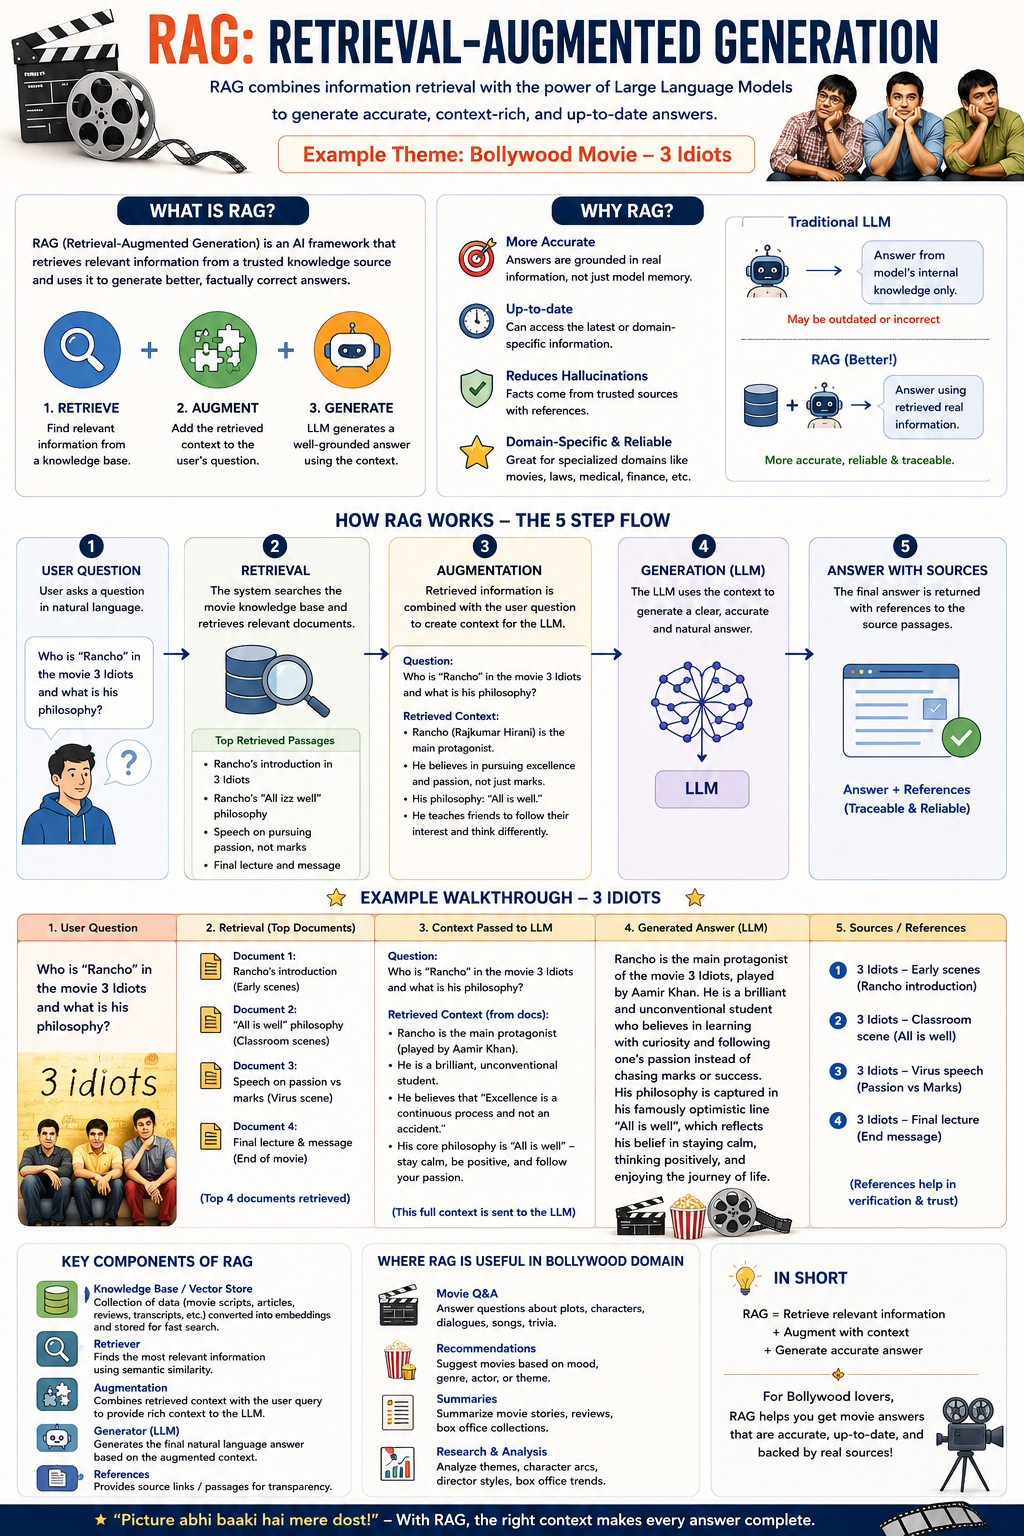

## The RAG Pipeline

```
User Query → Embed → Search Documents → Retrieve Top-K → Send to LLM → Response
```

The LLM generates answers **grounded** in your documents.

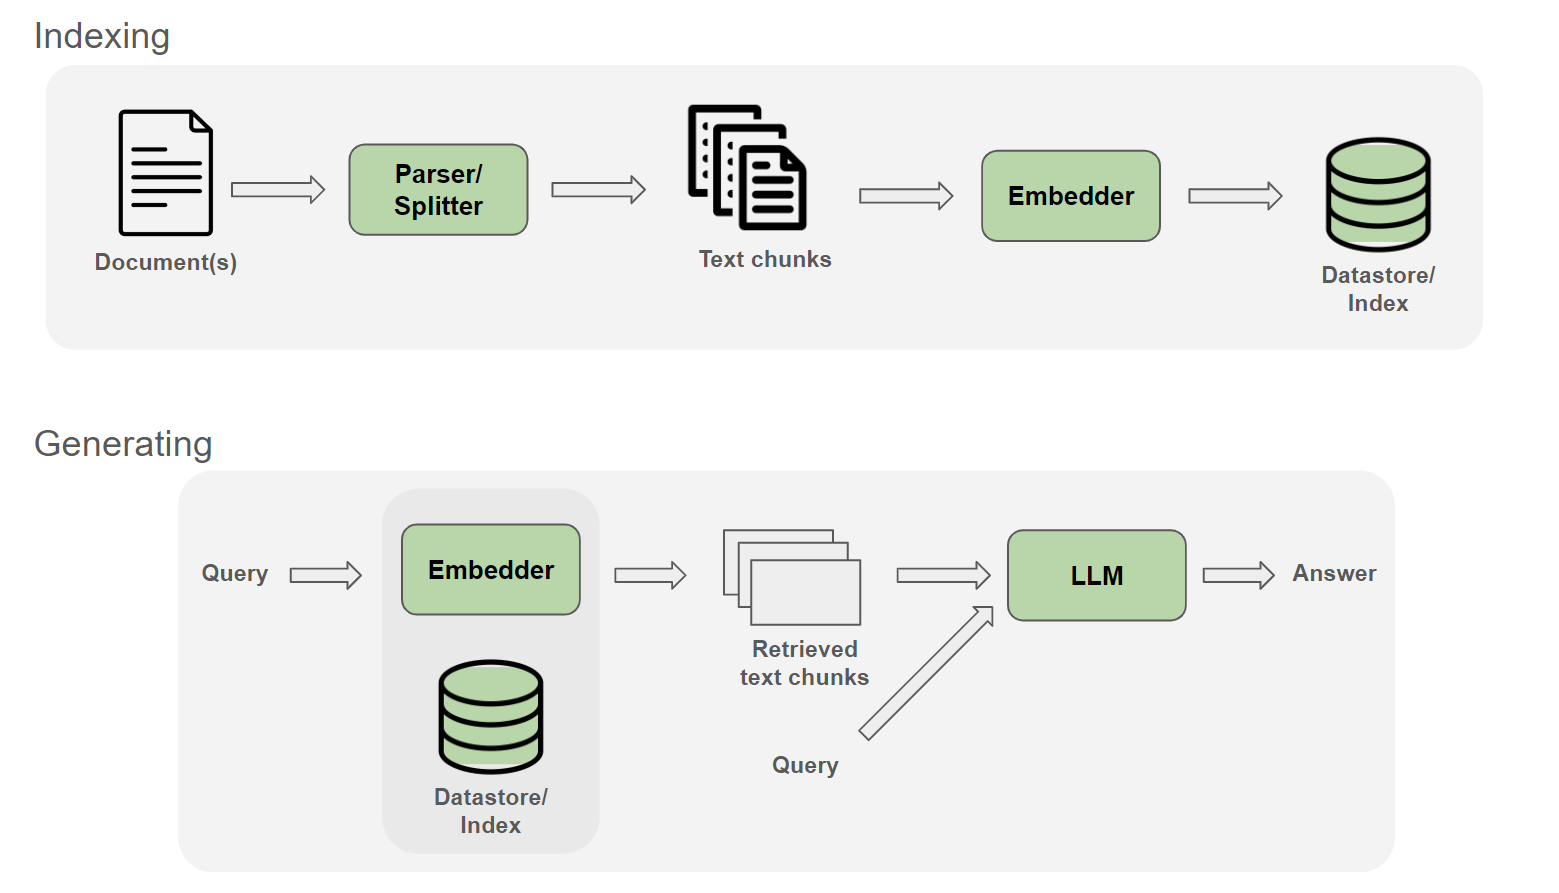

## Setup

In [8]:
from dotenv import load_dotenv
import os

load_dotenv()

key = os.getenv('GEMINI_API_KEY')
key[:4]

'AQ.A'

In [4]:
from google import genai
from google.genai import types
import os
from dotenv import load_dotenv
import numpy as np

# load_dotenv(dotenv_path='../.env')
# API_KEY = os.environ["GEMINI_API_KEY"]

from google.colab import userdata
API_KEY = userdata.get('GEMINI_API_KEY')

client = genai.Client(api_key=API_KEY)

def cosine_similarity(vec1, vec2):
    vec1 = np.array(vec1)
    vec2 = np.array(vec2)
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

## Knowledge Base

Our "private data" — information the LLM doesn't know.

In [5]:
knowledge_base = [
    "Our company's refund policy allows returns within 30 days of purchase.",
    "Premium members get free shipping on all orders over $25.",
    'We take the orders below $25 with $1 of delivery charge',
    "Customer support is available Monday to Friday, 9 AM to 6 PM EST.",
    "Gift cards can be purchased in denominations of $25, $50, and $100.",
    "Orders are typically delivered within 3-5 business days."
]

print("📚 Knowledge Base:")
for i, doc in enumerate(knowledge_base):
    print(f"  {i+1}. {doc}")

📚 Knowledge Base:
  1. Our company's refund policy allows returns within 30 days of purchase.
  2. Premium members get free shipping on all orders over $25.
  3. We take the orders below $25 with $1 of delivery charge
  4. Customer support is available Monday to Friday, 9 AM to 6 PM EST.
  5. Gift cards can be purchased in denominations of $25, $50, and $100.
  6. Orders are typically delivered within 3-5 business days.


## Index the Knowledge Base

In [9]:
# Generate embeddings for all documents
kb_embeddings = []
for doc in knowledge_base:
    response = client.models.embed_content(
        model="gemini-embedding-001",
        contents=doc
    )
    kb_embeddings.append(response.embeddings[0].values)

print(f"✅ Indexed {len(kb_embeddings)} documents")

✅ Indexed 6 documents


In [7]:
len(kb_embeddings[2])

3072

In [10]:
 kb_embeddings

[[-0.013071067,
  0.022788472,
  0.021055743,
  -0.0583385,
  0.0114865415,
  0.0021398815,
  0.011366342,
  -0.010267504,
  -0.016923536,
  -0.03556165,
  0.008148138,
  -0.015634865,
  -0.021771627,
  -0.019103257,
  0.10481489,
  -0.01902591,
  0.016184162,
  -0.013756163,
  -0.005260621,
  -0.0038892843,
  -0.0052832025,
  0.010383459,
  0.010232146,
  -0.01575346,
  -0.004097703,
  -0.0072241914,
  0.042767588,
  0.03686042,
  0.013116355,
  -0.012620702,
  -0.008214405,
  0.010371574,
  0.0020576152,
  -0.008369527,
  0.016443089,
  0.043447215,
  -0.0028306197,
  -0.011555335,
  -0.0059181857,
  0.0072130505,
  -0.029920172,
  -0.00019931333,
  0.01277459,
  -0.019937543,
  0.014242792,
  -0.015627312,
  0.008236026,
  -0.003930619,
  0.00903182,
  0.02051937,
  -0.031130122,
  -0.035298225,
  0.01018973,
  -0.1505676,
  -0.001300027,
  0.0028822438,
  -0.010442538,
  -0.0045289523,
  -0.0046616867,
  -0.0072295377,
  -0.012684741,
  0.01792685,
  -0.007897894,
  -0.032900024,
 

## Retrieval Function

In [12]:
def retrieve(query, top_k=3):
    """Find the most relevant documents for a query."""
    query_response = client.models.embed_content(
        model="gemini-embedding-001",
        contents=query
    )
    query_embedding = query_response.embeddings[0].values

    scores = []
    for i, doc_emb in enumerate(kb_embeddings):
        similarity = cosine_similarity(query_embedding, doc_emb)
        scores.append((similarity, i))

    scores.sort(reverse=True)

    return [knowledge_base[idx] for _, idx in scores[:top_k]]

## RAG Function

This is the core: **Retrieve** context, then **Generate** a response.

In [23]:
# Declaration of retrieve function
def rag(query):
    """Retrieval-Augmented Generation."""

    # Step 1: Retrieve relevant documents
    relevant_docs = retrieve(query, top_k=3)
    print('Relavant docs:',relevant_docs)

    # Step 2: Build the context
    context = "\n".join(f"- {doc}" for doc in relevant_docs)
    print('CONTEXT-',context)

    # Step 3: Create the prompt with context
    prompt = f"""

Context:
{context}

Question: {query}

Answer:"""

    # Step 4: Generate response
    response = client.models.generate_content(
        model="gemini-3.5-flash-lite",
        contents=prompt
    )

    return {
        "answer": response.text,
        "sources": relevant_docs
    }

## Test: Question About Refunds

In [24]:
query = "what is policy for the refund?"

print(f"❓ Question: {query}\n")
result = rag(query)

print(f"💬 Answer: {result['answer']}")
print(f"\n📄 Sources:")
for doc in result['sources']:
    print(f"  • {doc}")

❓ Question: what is policy for the refund?

Relavant docs: ["Our company's refund policy allows returns within 30 days of purchase.", 'We take the orders below $25 with $1 of delivery charge', 'Orders are typically delivered within 3-5 business days.']
CONTEXT- - Our company's refund policy allows returns within 30 days of purchase.
- We take the orders below $25 with $1 of delivery charge
- Orders are typically delivered within 3-5 business days.
💬 Answer: Based on the provided context, the refund policy allows returns within 30 days of purchase.

📄 Sources:
  • Our company's refund policy allows returns within 30 days of purchase.
  • We take the orders below $25 with $1 of delivery charge
  • Orders are typically delivered within 3-5 business days.


## Test: Question About Shipping

In [20]:
query = "What is the new for Premium members?"

print(f"❓ Question: {query}\n")
result = rag(query)

print(f"💬 Answer: {result['answer']}")
print(f"\n📄 Sources:")
for doc in result['sources']:
    print(f"  • {doc}")

❓ Question: What is the new for Premium members?

Relavant docs: ['Premium members get free shipping on all orders over $25.', 'Customer support is available Monday to Friday, 9 AM to 6 PM EST.', 'We take the orders below $25 with $1 of delivery charge']
CONTEXT- - Premium members get free shipping on all orders over $25.
- Customer support is available Monday to Friday, 9 AM to 6 PM EST.
- We take the orders below $25 with $1 of delivery charge
💬 Answer: Based on the provided context, Premium members get free shipping on all orders over $25.

📄 Sources:
  • Premium members get free shipping on all orders over $25.
  • Customer support is available Monday to Friday, 9 AM to 6 PM EST.
  • We take the orders below $25 with $1 of delivery charge


## Test: Question Not in Knowledge Base

In [25]:
query = "What is the ML?"

print(f"❓ Question: {query}\n")
result = rag(query)

print(f"💬 Answer: {result['answer']}")
print(f"\n📄 Sources (retrieved but not relevant):")
for doc in result['sources']:
    print(f"  • {doc}")

❓ Question: What is the ML?

Relavant docs: ['Customer support is available Monday to Friday, 9 AM to 6 PM EST.', 'Orders are typically delivered within 3-5 business days.', 'Gift cards can be purchased in denominations of $25, $50, and $100.']
CONTEXT- - Customer support is available Monday to Friday, 9 AM to 6 PM EST.
- Orders are typically delivered within 3-5 business days.
- Gift cards can be purchased in denominations of $25, $50, and $100.
💬 Answer: Based on the provided context, there is no mention of "ML". Therefore, the information is not available.

📄 Sources (retrieved but not relevant):
  • Customer support is available Monday to Friday, 9 AM to 6 PM EST.
  • Orders are typically delivered within 3-5 business days.
  • Gift cards can be purchased in denominations of $25, $50, and $100.


## Why RAG Works

1. **Grounded Responses** — Answers based on actual data, not hallucinations
2. **Up-to-date** — Just update the knowledge base, no retraining
3. **Transparent** — You can show the sources used
4. **Private** — Your data stays in your system

---

## Key Takeaways

1. **RAG = Retrieve + Generate**
2. Embed and index your documents **once**
3. For each query: retrieve relevant context, then prompt the LLM
4. Always provide sources for transparency

---

